In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/Acar3ds/final-project-TC6039-team-1/refs/heads/C1-Data-Loader/data/processed/df.csv'
df = pd.read_csv(url)
df.head()


,counter,date,hour,minute,day_type,weekday_number
0,1,2026-01-18,16,13,weekend,6
1,2,2026-01-18,16,13,weekend,6
2,3,2026-01-18,16,13,weekend,6
3,4,2026-01-18,16,13,weekend,6
4,5,2026-01-18,16,13,weekend,6


Loading and preparing data for the experiment pipeline...

--- Running Experiment: 1. Baseline (Hour only, Seq=3) ---
Done! R²: 0.6426 | wMAPE: 26.61% | RMSE: 26.58

--- Running Experiment: 2. Added Day 0-6 (Seq=3) ---
Done! R²: 0.6208 | wMAPE: 27.71% | RMSE: 27.38

--- Running Experiment: 3. Added Weekday 0-1 (Seq=3) ---
Done! R²: 0.6305 | wMAPE: 27.53% | RMSE: 27.03

--- Running Experiment: 4. Optimal Memory (Hour only, Seq=24) ---
Done! R²: 0.7630 | wMAPE: 20.76% | RMSE: 21.39

Generating final comparison report...

--- SUMMARY OF EXPERIMENTS ---
                             Scenario       R2  wMAPE (%)      RMSE       MAE
       1. Baseline (Hour only, Seq=3) 0.642627  26.611450 26.581138 18.921324
             2. Added Day 0-6 (Seq=3) 0.620803  27.713104 27.380745 19.704626
         3. Added Weekday 0-1 (Seq=3) 0.630461  27.527639 27.029798 19.572754
4. Optimal Memory (Hour only, Seq=24) 0.763019  20.759335 21.389925 15.121536


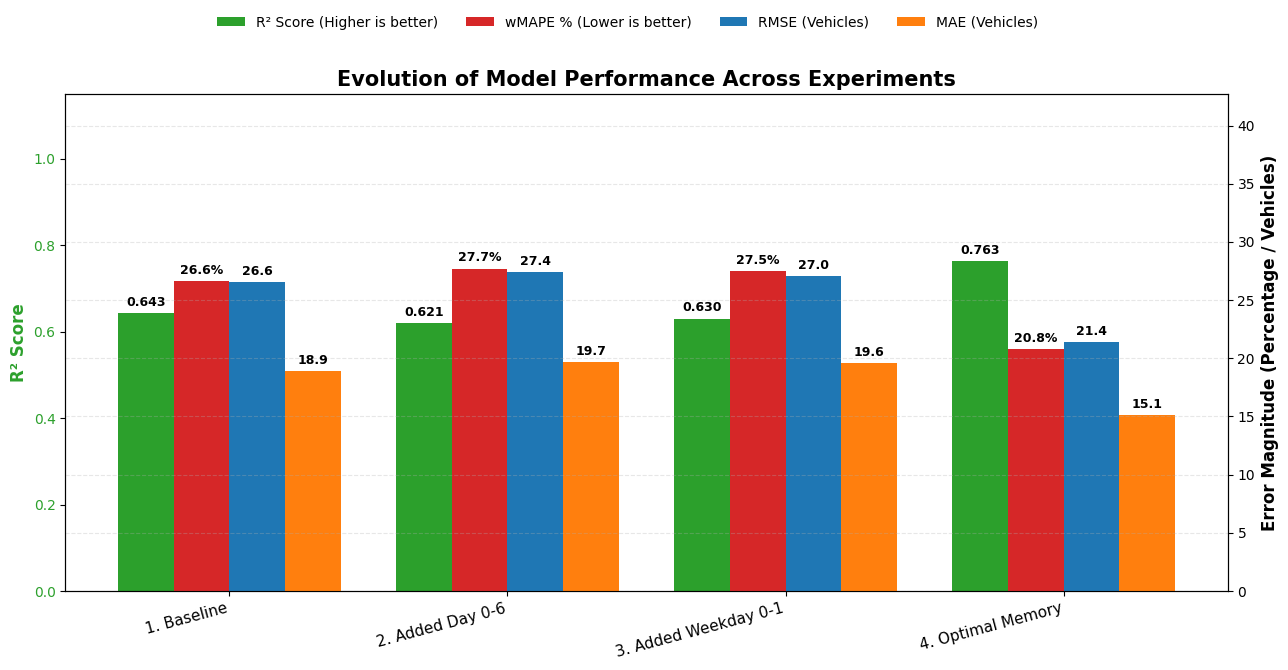

In [14]:
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ---------------------------------------------------------
# 1. Data Preparation
# ---------------------------------------------------------
print("Loading and preparing data for the experiment pipeline...")
url = 'https://raw.githubusercontent.com/Acar3ds/final-project-TC6039-team-1/refs/heads/C1-Data-Loader/data/processed/df.csv'
df = pd.read_csv(url)

# I group the data by date and hour to get my base target.
df_hourly = df.groupby(['date', 'hour']).size().reset_index(name='vehicles_per_hour')

# I create all the temporal features I will need for my different experiments.
df_hourly['date'] = pd.to_datetime(df_hourly['date'])
df_hourly['day_of_week'] = df_hourly['date'].dt.dayofweek          # 0 to 6
df_hourly['is_weekday'] = (df_hourly['day_of_week'] <= 4).astype(float) # 1 or 0

# ---------------------------------------------------------
# 2. Model Architecture
# ---------------------------------------------------------
# I define my standard LSTM architecture. It automatically adapts to the number of input features.
class TrafficLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(TrafficLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# ---------------------------------------------------------
# 3. Experiment Runner Function
# ---------------------------------------------------------
# I built this function to train and evaluate any scenario automatically.
def run_experiment(scenario_name, feature_columns, sequence_length):
    print(f"\n--- Running Experiment: {scenario_name} ---")

    # 1. Feature Extraction
    features = df_hourly[feature_columns].values
    target = df_hourly['vehicles_per_hour'].values.reshape(-1, 1)

    # 2. Scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    features_scaled = scaler_X.fit_transform(features)
    target_scaled = scaler_y.fit_transform(target)

    # 3. Sequence Generation
    X, y = [], []
    for i in range(len(features_scaled) - sequence_length):
        X.append(features_scaled[i:(i + sequence_length)])
        y.append(target_scaled[i + sequence_length])

    X = np.array(X)
    y = np.array(y)

    # 4. Train/Validation Split (80/20)
    split = int(0.8 * len(X))
    if split == 0: split = 1

    X_train, X_validation = X[:split], X[split:]
    y_train, y_validation = y[:split], y[split:]

    # Convert to PyTorch tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_validation, dtype=torch.float32) if len(X_validation) > 0 else X_train_t
    y_val_t = torch.tensor(y_validation, dtype=torch.float32) if len(X_validation) > 0 else y_train_t

    # 5. Initialization and Reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    input_size = X_train.shape[2]
    model = TrafficLSTM(input_size=input_size, hidden_size=64, num_layers=2, output_size=1)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

    best_val_loss = float('inf')
    best_model_weights = None

    # 6. Training Loop with Checkpointing
    epochs = 150
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t)

        # Save the best brain
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_weights = copy.deepcopy(model.state_dict())

    # 7. Evaluation using the best weights
    model.load_state_dict(best_model_weights)
    model.eval()
    with torch.no_grad():
        predictions_scaled = model(X_val_t).numpy()
        y_val_scaled = y_val_t.numpy()

    # Inverse transform
    predictions = scaler_y.inverse_transform(predictions_scaled)
    y_val_real = scaler_y.inverse_transform(y_val_scaled)

    # 8. Calculate Metrics
    rmse = np.sqrt(mean_squared_error(y_val_real, predictions))
    r2 = r2_score(y_val_real, predictions) if len(y_val_real) > 1 else float('nan')
    mae = mean_absolute_error(y_val_real, predictions)
    wmape = (np.sum(np.abs(y_val_real - predictions)) / np.sum(y_val_real)) * 100

    print(f"Done! R²: {r2:.4f} | wMAPE: {wmape:.2f}% | RMSE: {rmse:.2f}")

    return {
        'Scenario': scenario_name,
        'R2': r2,
        'wMAPE (%)': wmape,
        'RMSE': rmse,
        'MAE': mae
    }

# ---------------------------------------------------------
# 4. Defining and Running the Scenarios
# ---------------------------------------------------------
# Here I define the exact history of my experimentation process.
scenarios_to_test = [
    {
        'name': '1. Baseline (Hour only, Seq=3)',
        'features': ['hour', 'vehicles_per_hour'],
        'seq': 3
    },
    {
        'name': '2. Added Day 0-6 (Seq=3)',
        'features': ['day_of_week', 'hour', 'vehicles_per_hour'],
        'seq': 3
    },
    {
        'name': '3. Added Weekday 0-1 (Seq=3)',
        'features': ['is_weekday', 'hour', 'vehicles_per_hour'],
        'seq': 3
    },
    {
        'name': '4. Optimal Memory (Hour only, Seq=24)',
        'features': ['hour', 'vehicles_per_hour'],
        'seq': 24
    }
]

# I store the results of all experiments in a list.
results_list = []
for config in scenarios_to_test:
    result = run_experiment(config['name'], config['features'], config['seq'])
    results_list.append(result)

# ---------------------------------------------------------
# 5. Visualizing the Experiment History
# ---------------------------------------------------------
print("\nGenerating final comparison report...")

# I convert the results into a Pandas DataFrame for a clean table view.
df_results = pd.DataFrame(results_list)
print("\n--- SUMMARY OF EXPERIMENTS ---")
print(df_results.to_string(index=False))

# Now, I plot the results to show how the model improved over time.
fig, ax1 = plt.subplots(figsize=(15, 7)) # Slightly wider to fit 4 bars

# X-axis labels
scenarios = df_results['Scenario']
x_pos = np.arange(len(scenarios))

# Bar width adjusted for 4 bars per scenario
width = 0.2

# Plot R² on the primary Y-axis (Higher is better)
# X positions: -1.5*width, -0.5*width, +0.5*width, +1.5*width
rects1 = ax1.bar(x_pos - 1.5 * width, df_results['R2'], width, label='R² Score (Higher is better)', color='#2ca02c')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold', color='#2ca02c')
ax1.tick_params(axis='y', labelcolor='#2ca02c')
ax1.set_ylim(0, 1.15) # Extra space to prevent labels overlapping with the legend

# Create a secondary Y-axis for Error Metrics (Lower is better)
ax2 = ax1.twinx()

# Plot wMAPE, RMSE, and MAE on the secondary axis
rects2 = ax2.bar(x_pos - 0.5 * width, df_results['wMAPE (%)'], width, label='wMAPE % (Lower is better)', color='#d62728')
rects3 = ax2.bar(x_pos + 0.5 * width, df_results['RMSE'], width, label='RMSE (Vehicles)', color='#1f77b4')
rects4 = ax2.bar(x_pos + 1.5 * width, df_results['MAE'], width, label='MAE (Vehicles)', color='#ff7f0e')

ax2.set_ylabel('Error Magnitude (Percentage / Vehicles)', fontsize=12, fontweight='bold', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Set Y limit based on the max value of any of our 3 error metrics
max_error = max(df_results['wMAPE (%)'].max(), df_results['RMSE'].max(), df_results['MAE'].max())
ax2.set_ylim(0, max_error + 15)

# Title and X-axis configuration
plt.title('Evolution of Model Performance Across Experiments', fontsize=15, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([s.split('(')[0].strip() for s in scenarios], rotation=15, ha='right', fontsize=11)

# Centralized Legend for all 4 metrics
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# Setting ncol=4 so the legend spreads horizontally across the top
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=4, frameon=False, fontsize=10)

# Helper function to add exact numbers on top of the bars
def autolabel(rects, ax, format_str='{:.2f}'):
    for rect in rects:
        height = rect.get_height()
        label = format_str.format(height)
        ax.annotate(label,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Labeling all 4 sets of bars
autolabel(rects1, ax1, format_str='{:.3f}')
autolabel(rects2, ax2, format_str='{:.1f}%')
autolabel(rects3, ax2, format_str='{:.1f}')
autolabel(rects4, ax2, format_str='{:.1f}')

# Adjust layout to make room for the large legend at the top
plt.subplots_adjust(top=0.82)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.show()

Total loaded records: 74324

Training the LSTM model and searching for the optimal weights...
Training completed! The best model was found at Epoch 148 with a Loss of 0.000427

--- OPTIMAL RESULTS FOR MODULE C5 ---
RMSE (Root Mean Squared Error): 21.39 vehicles/hour
R² (Coefficient of Determination): 0.7630


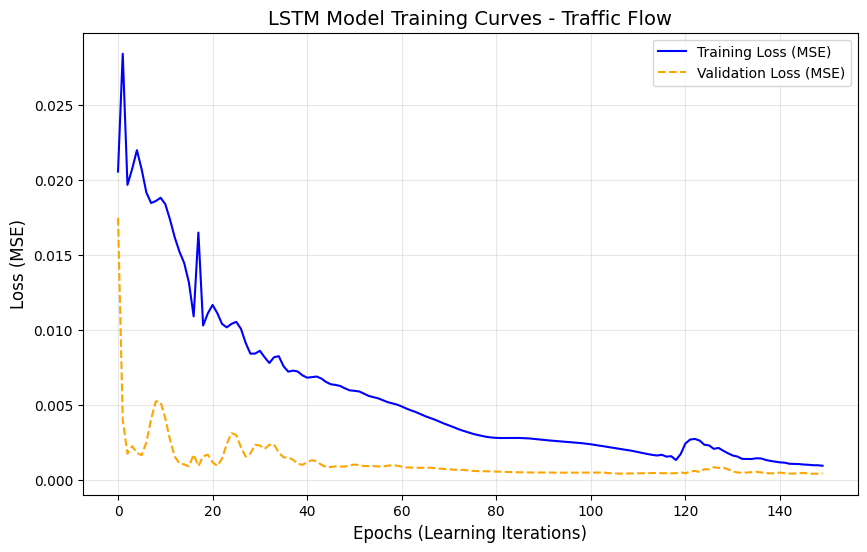


Preparing data for the workweek visualization...

--- SHOWING WEEK FROM 2026-01-19 TO 2026-01-23 ---


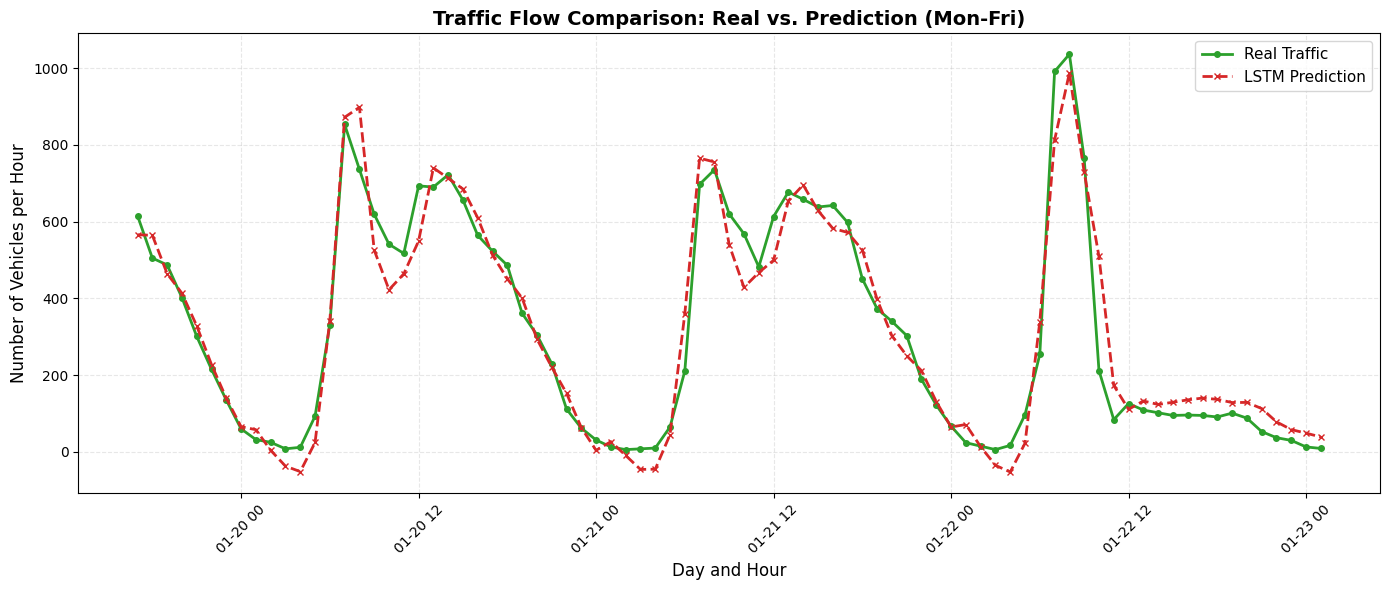


Calculating advanced business metrics and generating diagnostic plots...

--- BUSINESS METRICS ---
MAE (Mean Absolute Error): 15.12 vehicles/hour
wMAPE (Weighted Percentage Error): 20.76%


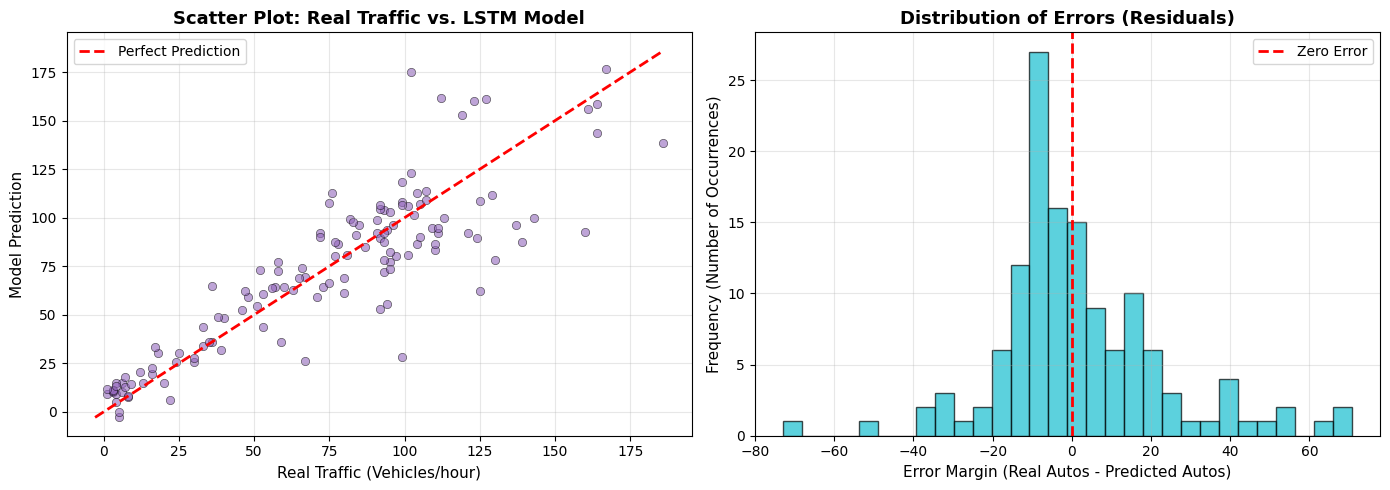

In [12]:
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ---------------------------------------------------------
# 1. Original Data Loading
# ---------------------------------------------------------
# Here I define the URL of our processed dataset and load it into a pandas DataFrame.
url = 'https://raw.githubusercontent.com/Acar3ds/final-project-TC6039-team-1/refs/heads/C1-Data-Loader/data/processed/df.csv'
df = pd.read_csv(url)
print(f"Total loaded records: {len(df)}")

# ---------------------------------------------------------
# 2. Preprocessing (Hourly Grouping and Sequencing)
# ---------------------------------------------------------
# First, I group the raw detections by date and hour to get the total vehicles per hour.
df_hourly = df.groupby(['date', 'hour']).size().reset_index(name='vehicles_per_hour')

# I check if there's enough data to create sequences.
# If the dataset is too small, I force a window of size 1.
if len(df_hourly) < 5:
    print("\nWarning: The data chunk is too small (very few hours).")
    print("For a sequence model (Deep Learning), I need more recorded hours.")
    sequence_length = 1
else:
    # I set a memory window of 24 hours. This means my model will look at the past 24 hours to predict the next one.
    sequence_length = 24

# I extract the features (hour and vehicles) and the target variable (vehicles).
features = df_hourly[['hour', 'vehicles_per_hour']].values
target = df_hourly['vehicles_per_hour'].values.reshape(-1, 1)

# I scale the data using Min-Max Normalization to help the neural network learn faster and avoid mathematical bias.
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
features_scaled = scaler_X.fit_transform(features)
target_scaled = scaler_y.fit_transform(target)

# Here I generate the sliding window tensors for my LSTM.
X, y = [], []
for i in range(len(features_scaled) - sequence_length):
    X.append(features_scaled[i:(i + sequence_length)])
    y.append(target_scaled[i + sequence_length])

X = np.array(X)
y = np.array(y)

# I split my data into Training and Validation sets (80/20).
split = int(0.8 * len(X))
# Fallback just in case the dataset is extremely small.
if split == 0:
    split = 1

X_train, X_validation = X[:split], X[split:]
y_train, y_validation = y[:split], y[split:]

# ---------------------------------------------------------
# 3. Deep Learning Architecture (PyTorch LSTM)
# ---------------------------------------------------------
# I build my custom neural network class inheriting from PyTorch's nn.Module.
class TrafficLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(TrafficLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # I define the LSTM layer with batch_first=True for easier tensor handling.
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # I add a fully connected linear layer to map the LSTM output to my single prediction.
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # I initialize the hidden state and cell state with zeros.
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # I pass the input through the LSTM.
        out, _ = self.lstm(x, (h0, c0))

        # I only care about the prediction from the very last time step.
        out = self.fc(out[:, -1, :])
        return out

# ---------------------------------------------------------
# 4. Training, Evaluation, and Checkpointing
# ---------------------------------------------------------
# I fix the random seeds so my results are fully reproducible every time I run the code.
torch.manual_seed(42)
np.random.seed(42)

# I convert my numpy arrays to PyTorch float32 tensors.
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

if len(X_validation) > 0:
    X_val_t = torch.tensor(X_validation, dtype=torch.float32)
    y_val_t = torch.tensor(y_validation, dtype=torch.float32)
else:
    X_val_t, y_val_t = X_train_t, y_train_t

# I set up the model configurations, loss function (MSE), and the Adam optimizer.
input_size = X_train.shape[2]
model = TrafficLSTM(input_size=input_size, hidden_size=64, num_layers=2, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

epochs = 150
train_losses = []
val_losses = []

# Variables to keep track of my best model state during training.
best_val_loss = float('inf')
best_model_weights = None
best_epoch = 0

print("\nTraining the LSTM model and searching for the optimal weights...")
for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

    # --- Checkpointing Logic ---
    # If I find a lower validation loss, I save a deep copy of the model's "brain" (weights).
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_epoch = epoch
        best_model_weights = copy.deepcopy(model.state_dict())

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

print(f"Training completed! The best model was found at Epoch {best_epoch} with a Loss of {best_val_loss:.6f}")

# I replace the current model's weights with the best ones I found during training.
model.load_state_dict(best_model_weights)

# I make the final predictions using this optimal model.
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_val_t).numpy()
    y_val_scaled = y_val_t.numpy()

# I reverse the Min-Max scaling to get real "Vehicles per Hour" numbers.
predictions = scaler_y.inverse_transform(predictions_scaled)
y_val_real = scaler_y.inverse_transform(y_val_scaled)

# I calculate my main baseline metrics.
rmse = np.sqrt(mean_squared_error(y_val_real, predictions))
if len(y_val_real) > 1:
    r2 = r2_score(y_val_real, predictions)
else:
    r2 = float('nan')

print("\n--- OPTIMAL RESULTS FOR MODULE C5 ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} vehicles/hour")
if not np.isnan(r2):
    print(f"R² (Coefficient of Determination): {r2:.4f}")

# ---------------------------------------------------------
# 5. Training Curves Visualization
# ---------------------------------------------------------
# Here I plot the training and validation losses to ensure my model isn't overfitting.
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss (MSE)', color='blue')
plt.plot(val_losses, label='Validation Loss (MSE)', color='orange', linestyle='--')
plt.title('LSTM Model Training Curves - Traffic Flow', fontsize=14)
plt.xlabel('Epochs (Learning Iterations)', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 6. Workweek Prediction & Comparison (Monday to Friday)
# ---------------------------------------------------------
print("\nPreparing data for the workweek visualization...")

# I convert the 'date' column into a proper Pandas datetime format.
df_hourly['date'] = pd.to_datetime(df_hourly['date'])

# I identify the day of the week (0 = Monday, 6 = Sunday).
df_hourly['day_of_week'] = df_hourly['date'].dt.dayofweek

# I create a unified datetime column by adding the hour so I can plot it fluidly.
df_hourly['datetime'] = df_hourly['date'] + pd.to_timedelta(df_hourly['hour'], unit='h')

# I run the model over all possible data points to get a continuous prediction curve.
X_all_t = torch.tensor(X, dtype=torch.float32)
model.eval()
with torch.no_grad():
    all_predictions_scaled = model(X_all_t).numpy()

# I reverse the normalization to get real vehicle counts.
all_predictions_real = scaler_y.inverse_transform(all_predictions_scaled)
all_targets_real = scaler_y.inverse_transform(y.reshape(-1, 1))

# I align my predictions with the original DataFrame (skipping the first sequence_length rows).
df_results = df_hourly.iloc[sequence_length:].copy()
df_results['Predicted'] = all_predictions_real
df_results['Real'] = all_targets_real

# I filter out the weekends to focus only on weekdays (Monday=0 to Friday=4).
df_weekdays = df_results[df_results['day_of_week'] <= 4].copy()

# I search for the first available Monday in the dataset to plot a full continuous week.
first_monday = df_weekdays[df_weekdays['day_of_week'] == 0]['date'].min()

if pd.isna(first_monday):
    print("Warning: No weekday (Monday) data found in the dataset to plot.")
else:
    # I calculate the Friday of that exact same week.
    first_friday = first_monday + pd.Timedelta(days=4)

    # I extract just the chunk of that specific week.
    df_week = df_weekdays[(df_weekdays['date'] >= first_monday) & (df_weekdays['date'] <= first_friday)]

    print(f"\n--- SHOWING WEEK FROM {first_monday.date()} TO {first_friday.date()} ---")

    # Now, I plot the real vs. predicted comparison.
    plt.figure(figsize=(14, 6))

    plt.plot(df_week['datetime'], df_week['Real'],
             label='Real Traffic', color='#2ca02c', marker='o', markersize=4, linewidth=2)

    plt.plot(df_week['datetime'], df_week['Predicted'],
             label='LSTM Prediction', color='#d62728', linestyle='--', marker='x', markersize=4, linewidth=2)

    plt.title('Traffic Flow Comparison: Real vs. Prediction (Mon-Fri)', fontsize=14, fontweight='bold')
    plt.xlabel('Day and Hour', fontsize=12)
    plt.ylabel('Number of Vehicles per Hour', fontsize=12)

    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 7. Business Metrics and Advanced Error Diagnostics
# ---------------------------------------------------------
print("\nCalculating advanced business metrics and generating diagnostic plots...")

# I calculate the Mean Absolute Error (MAE) for a more intuitive business interpretation.
mae = mean_absolute_error(y_val_real, predictions)

# I calculate the Mean Absolute Percentage Error (MAPE).
# I add +1 to the denominator to prevent division by zero during empty night hours.
wmape = (np.sum(np.abs(y_val_real - predictions)) / np.sum(y_val_real)) * 100

print("\n--- BUSINESS METRICS ---")
print(f"MAE (Mean Absolute Error): {mae:.2f} vehicles/hour")
print(f"wMAPE (Weighted Percentage Error): {wmape:.2f}%")

# I set up a figure to display two error diagnostic plots side by side.
plt.figure(figsize=(14, 5))

# --- PLOT 1: Scatter (Real vs Predicted) ---
plt.subplot(1, 2, 1)
plt.scatter(y_val_real, predictions, alpha=0.6, color='#9467bd', edgecolors='k', linewidth=0.5)

# I draw the perfect prediction diagonal red dashed line.
max_val = max(y_val_real.max(), predictions.max())
min_val = min(y_val_real.min(), predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Scatter Plot: Real Traffic vs. LSTM Model', fontsize=13, fontweight='bold')
plt.xlabel('Real Traffic (Vehicles/hour)', fontsize=11)
plt.ylabel('Model Prediction', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

# --- PLOT 2: Residuals Histogram (Errors) ---
# I calculate the residuals, which is simply the difference between reality and my prediction.
residuals = y_val_real - predictions

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, color='#17becf', edgecolor='black', alpha=0.7)

# I draw a vertical line at zero to easily spot if my model is biased.
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')

plt.title('Distribution of Errors (Residuals)', fontsize=13, fontweight='bold')
plt.xlabel('Error Margin (Real Autos - Predicted Autos)', fontsize=11)
plt.ylabel('Frequency (Number of Occurrences)', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

# I adjust the layout and display the final diagnostic plots.
plt.tight_layout()
plt.show()